In [1]:
import os
import sys
import glob
import scipy as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

sys.path.insert(1, './utils')

from utils import * 
from plotUtils import *
from fcMeasure import *

%matplotlib inline
plt.rcParams.update({'font.size': 14})

In [2]:
# Reading connectivity matrix from OSF data

root_data = "./data"

AALMAp = pd.read_csv("./data/AAL_regions.csv", sep=";")
ROI = AALMAp['ROI number'].to_numpy()
ROI_tags = AALMAp['ROI name'].to_numpy()

In [3]:
_scfiles = sorted(glob.glob(os.path.join(root_data, "S*.csv")))
print(f"No. of SC files = {len(_scfiles)}")

No. of SC files = 88


In [4]:
N = 90
meanA = np.zeros((N, N))

for _sc in _scfiles:
    A = pd.read_csv(_sc, header=None).to_numpy()
    A = (A + A.T) / 2                       # Symetrizes the matrices
    meanA += (1 / len(_scfiles)) * A

(0.0, 0.44964212382954544)

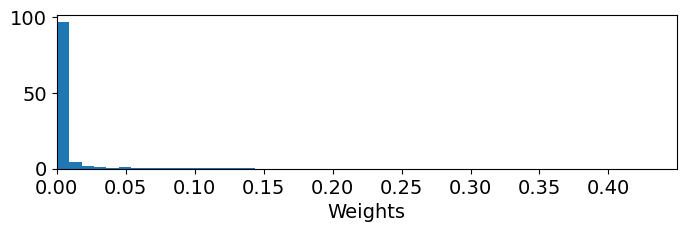

In [5]:
undirect_weights = meanA[np.triu_indices(N, k=1)]

# plotting macro-scale connection probabilities
plt.figure(figsize=(8, 2))
h = plt.hist(undirect_weights, bins=50, density=True, rwidth=11)
plt.xlabel('Weights')
plt.xlim(np.min(undirect_weights), np.max(undirect_weights))

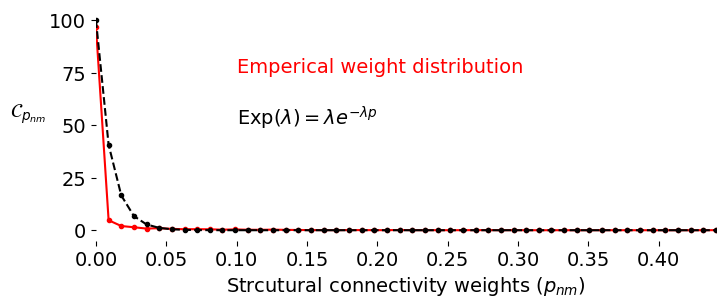

In [6]:
plt.figure(figsize=(8, 3))
plt.plot(h[1][:-1], h[0], '.-', color='r')
plt.plot(h[1][:-1], 100 * np.exp(-100 * h[1][:-1]), '.--', color='k')
plt.xlim(h[1][0], h[1][-2])
plt.xlabel(r"Strcutural connectivity weights $(p_{nm})$")
plt.ylabel(r"$\mathcal{C}_{p_{nm}}$", rotation=0, labelpad=15)
plt.text(0.1, 75, "Emperical weight distribution", color='r')
plt.text(0.1, 50, r"$\mathrm{Exp}(\lambda) = \lambda e^{-\lambda p}$", color='k')
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

In [7]:
# creating a sub graph from right hemisphere ROIs

RightROIs = ROI[1 :: 2] - 1
nNodes = 10

RandomROIS = RightROIs[15 : 15 + nNodes] # np.array(random.sample(list(RightROIs), k=nNodes))
RandomROI_tags = ROI_tags[RandomROIS]
meanAsub = meanA[RandomROIS, :][:, RandomROIS]

(6.338156818181818e-06, 0.3008163252284091)

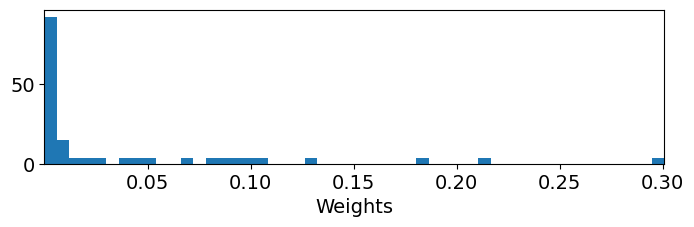

In [8]:
undirect_weights_sub = meanAsub[np.triu_indices(nNodes, k=1)]

# plotting macro-scale connection probabilities
plt.figure(figsize=(8, 2))
h = plt.hist(undirect_weights_sub, bins=50, density=True, rwidth=11)
plt.xlabel('Weights')
plt.xlim(np.min(undirect_weights_sub), np.max(undirect_weights_sub))

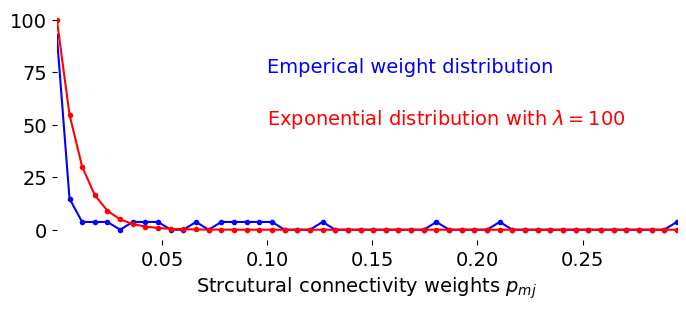

In [9]:
plt.figure(figsize=(8, 3))
plt.plot(h[1][:-1], h[0], '.-', color='blue')
plt.plot(h[1][:-1], 100 * np.exp(-100 * h[1][:-1]), '.-', color='red')
plt.xlim(h[1][0], h[1][-2])
plt.xlabel(r"Strcutural connectivity weights $p_{mj}$")
plt.text(0.1, 75, "Emperical weight distribution", color='blue')
plt.text(0.1, 50, r"Exponential distribution with $\lambda = 100$", color='red')
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

In [10]:
# Scaling
normalization_factor = np.max(np.abs(meanAsub.sum(axis=1)))
meanAsub_norm = meanAsub / normalization_factor

(1.0582659977835008e-05, 0.5022654025444727)

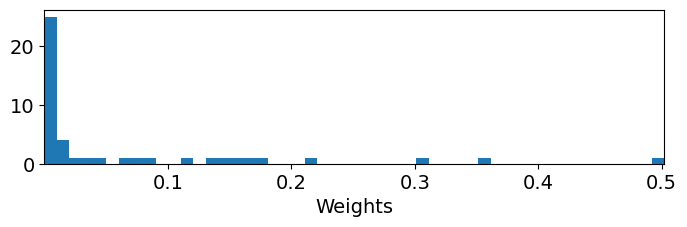

In [11]:
undirect_weights_sub = meanAsub_norm[np.triu_indices(nNodes, k=1)]

# plotting macro-scale connection probabilities
plt.figure(figsize=(8, 2))
h = plt.hist(undirect_weights_sub, bins=50, density=False, rwidth=11)
plt.xlabel('Weights')
plt.xlim(np.min(undirect_weights_sub), np.max(undirect_weights_sub))

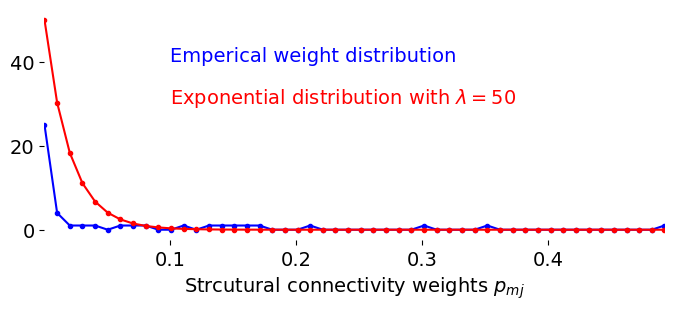

In [12]:
plt.figure(figsize=(8, 3))
plt.plot(h[1][:-1], h[0], '.-', color='blue')
plt.plot(h[1][:-1], 50 * np.exp(-50 * h[1][:-1]), '.-', color='red')
plt.xlim(h[1][0], h[1][-2])
plt.xlabel(r"Strcutural connectivity weights $p_{mj}$")
plt.text(0.1, 40, "Emperical weight distribution", color='blue')
plt.text(0.1, 30, r"Exponential distribution with $\lambda = 50$", color='red')
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)